In [5]:
#Libraries used: pandas and numpy for data manipulation, matplotlib/seaborn for
#visualization, sklearn for modeling.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
smart = pd.read_csv("Cleaned_EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv")

## **Variables**
* **Activity Density (D1D)**: The concentration of housing and jobs in the neighborhood. Higher values represent dense, urban areas with lots of people and jobs packed, while lower values represent suburban or rural areas with fewer people and jobs spread out over more land.

* **Employment Mix (D2B_E5MIX)**: The variety of job types in the area. A higher score means a healthy mix of different industries (like retail, office, and service jobs), rather than just one type of business.

* **Street Connectivity (D3B)**: How well the streets connect to each other. It measures the ratio of intersections to street segments. More intersections mean a grid-like layout that is easy to walk, while fewer intersections mean more dead-ends or long highways.

* **Distance to Transit (D4A)**: The distance from the center of the neighborhood to the nearest public transportation stop.

* **National Walkability Index (NatWalkInd)**: The original score from the EPA dataset that measures how walkable a block is.

* **Walkability**: The final yes/no variable created for this project. It turns the original EPA score into a simple '1' (Walkable) or '0' (Not Walkable) for the model to predict.

In [6]:
#Block groups with D4A = -99999 had no nearby transit and are removed to avoid
#distorting distance-based models.
#Walkability is recorded as binary: 0 = Not Walkable, 1 = Walkable
clean_smart = smart[smart['D4A'] > 0].copy()
clean_smart['Walkability'] = 1*((clean_smart['Cat_NatWalkInd'] == 'Above average walkable') |
                                (clean_smart['Cat_NatWalkInd'] == 'Most walkable'))

In [7]:
#Checking dataset shape after cleaning
clean_smart.shape

(91090, 6)

In [8]:
#Splitting the dataset into 80% training data and 20% testing data
train_smart = clean_smart.sample(frac=0.8, random_state=0)
test_smart = clean_smart.drop(train_smart.index)

In [9]:
#Splitting the data for tuning, where 80% of tuning comes from the training data, and 20% for validation.
train_smart_tune = train_smart.sample(frac=0.8, random_state=0)
train_smart_validation = train_smart.drop(train_smart_tune.index)

In [10]:
train_smart_tune.shape

(58298, 6)

In [11]:
#Standard deviations of predictiors in the training set
#Large differences in scale motivate normalization for KNN
train_smart[['D1D', 'D2B_E5MIX', 'D3B', 'D4A']].std()

,0
D1D,81.508986
D2B_E5MIX,0.256381
D3B,89.671670
D4A,272.477425


### **Understand the Problem & Data**
The dataset contains 220,740 census block groups. After removing observations with no nearby transit (D4A = -99999), we retain 91,090 observations.
We explore each predictor visually before modeling.

Text(0.5, 1.0, 'Histogram of Activity Density in Non-Walkable Areas')

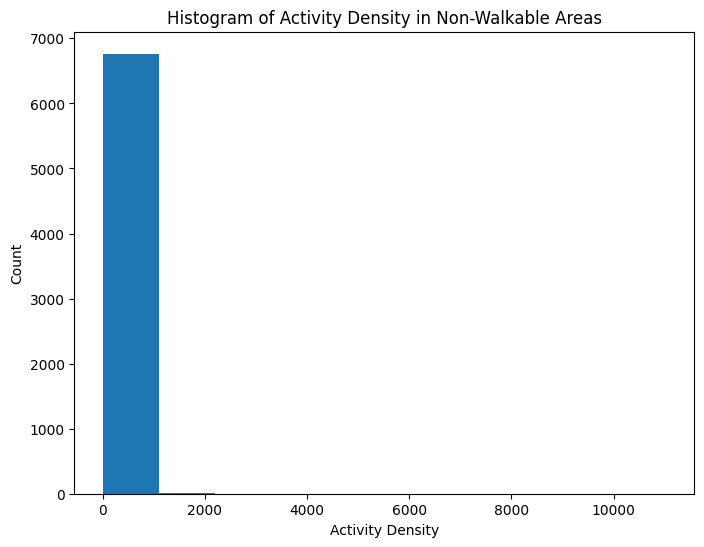

In [70]:
#Checking D1D vs Walkability
plt.figure(figsize=(8, 6))
plt.hist(train_smart[train_smart['Walkability'] == 0]['D1D'])
plt.xlabel('Activity Density')
plt.ylabel('Count')
plt.title('Histogram of Activity Density in Non-Walkable Areas')

Text(0.5, 1.0, 'Histogram of Activity Density in Walkable Areas')

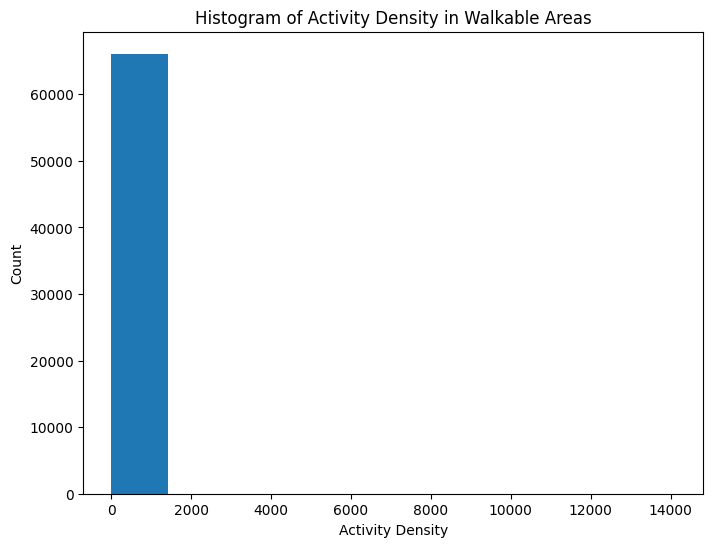

In [13]:
#Checking D1D vs Walkability
plt.figure(figsize=(8, 6))
plt.hist(train_smart[train_smart['Walkability'] == 1]['D1D'], bins=10)
plt.xlabel('Activity Density')
plt.ylabel('Count')
plt.title('Histogram of Activity Density in Walkable Areas')

Text(0.5, 1.0, 'Log-Transformed Histogram of Activity Density in Non-Walkable Areas')

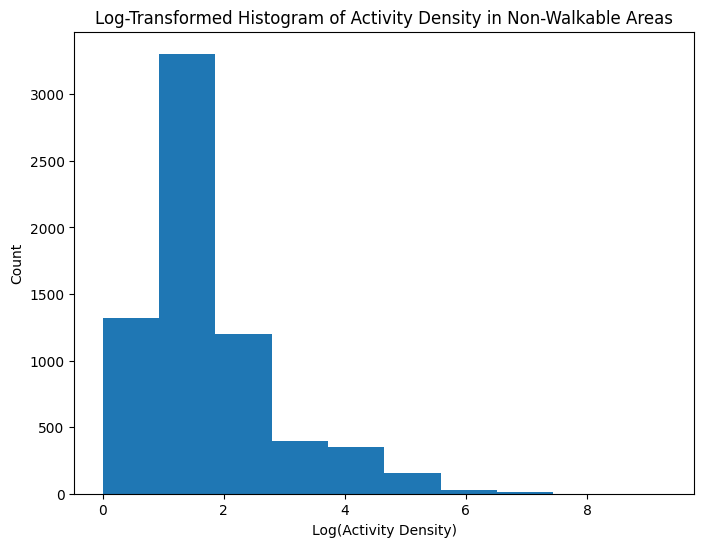

In [73]:
#Log Transformation (log1p shifts everything by adding +1 before logging avoiding zeros becoming -inf)
log1no = train_smart[train_smart['Walkability'] == 0]['D1D']
log1_datano = np.log1p(log1no)
plt.figure(figsize=(8, 6))
plt.hist(log1_datano)
plt.xlabel('Log(Activity Density)')
plt.ylabel('Count')
plt.title('Log-Transformed Histogram of Activity Density in Non-Walkable Areas')


Text(0.5, 1.0, 'Log-Transformed Histogram of Activity Density in Walkable Areas')

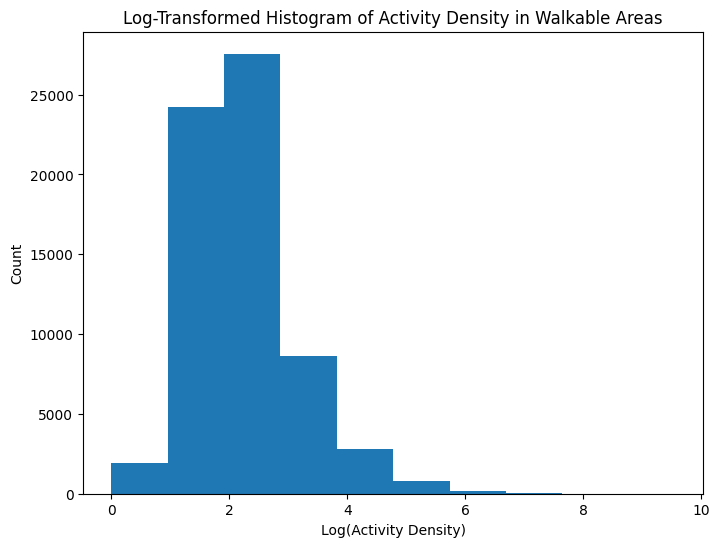

In [15]:
#Log Transformation (log1p shifts everything by adding +1 before logging avoiding zeros becoming -inf)
log1yes = train_smart[train_smart['Walkability'] == 1]['D1D']
log1_datayes = np.log1p(log1yes)
plt.figure(figsize=(8, 6))
plt.hist(log1_datayes)
plt.xlabel('Log(Activity Density)')
plt.ylabel('Count')
plt.title('Log-Transformed Histogram of Activity Density in Walkable Areas')


Text(0.5, 1.0, 'Number of Employment Diversity (D2B_E5MIX) vs. Walkability')

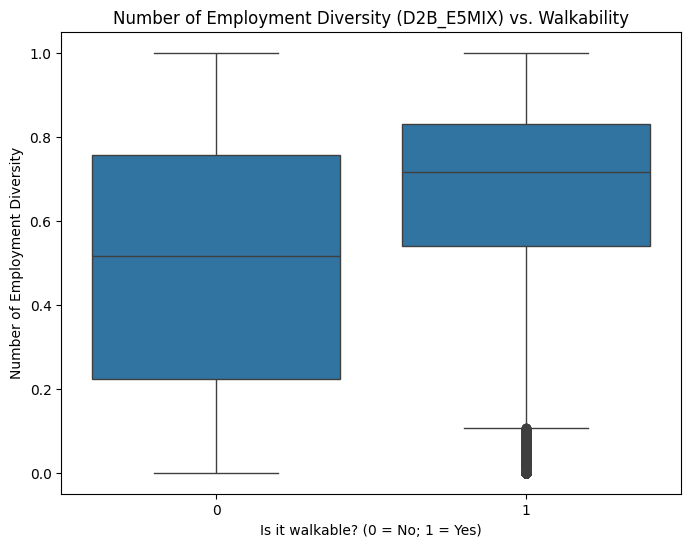

In [16]:
#Checking D2B_E5MIX vs Walkability
plt.figure(figsize=(8, 6))
sns.boxplot(x = train_smart['Walkability'], y = train_smart['D2B_E5MIX'])
plt.xlabel('Is it walkable? (0 = No; 1 = Yes)')
plt.ylabel('Number of Employment Diversity')
plt.title('Number of Employment Diversity (D2B_E5MIX) vs. Walkability')

Text(0.5, 1.0, 'Histogram of Street Connectivity (D3B) in Non-Walkable Areas')

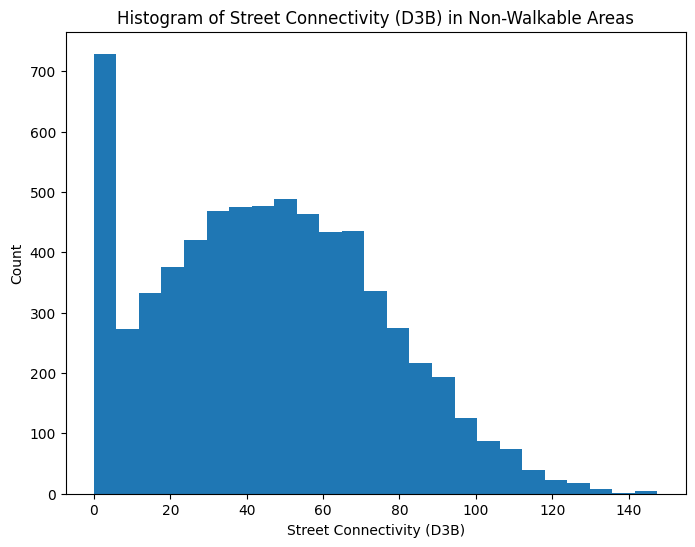

In [17]:
#Checking D3B vs Walkability
plt.figure(figsize=(8, 6))
plt.hist(train_smart[train_smart['Walkability'] == 0]['D3B'], bins=25)
plt.xlabel('Street Connectivity (D3B)')
plt.ylabel('Count')
plt.title('Histogram of Street Connectivity (D3B) in Non-Walkable Areas')

Text(0.5, 1.0, 'Histogram of Street Connectivity (D3B) in Walkable Areas')

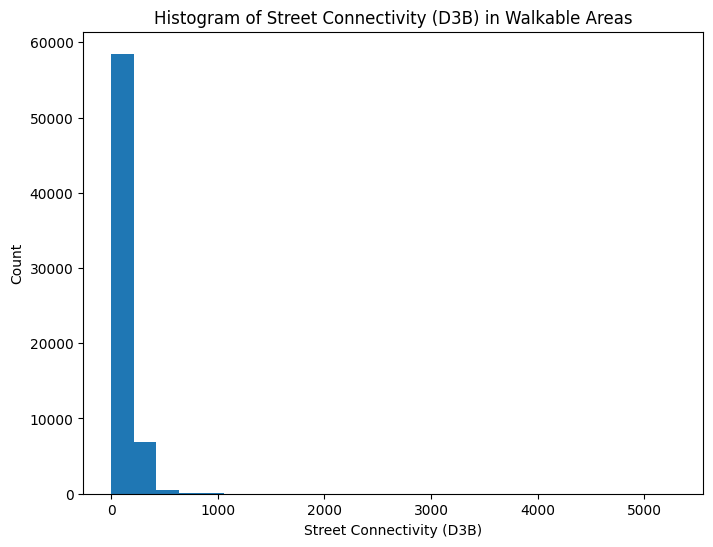

In [18]:
#Checking D3B vs Walkability
plt.figure(figsize=(8, 6))
plt.hist(train_smart[train_smart['Walkability'] == 1]['D3B'], bins=25)
plt.xlabel('Street Connectivity (D3B)')
plt.ylabel('Count')
plt.title('Histogram of Street Connectivity (D3B) in Walkable Areas')

Text(0.5, 1.0, 'Distance to Transit (D4A) vs. Walkability')

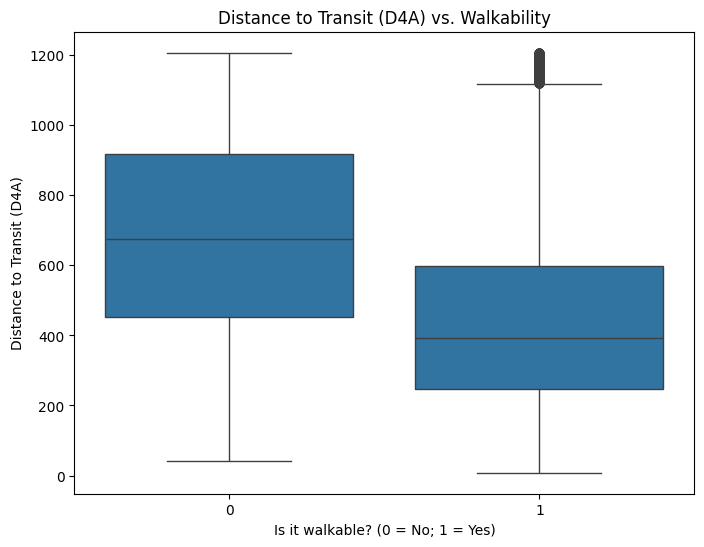

In [19]:
#Checking D4A vs Walkability
plt.figure(figsize=(8, 6))
sns.boxplot(x = train_smart['Walkability'], y = train_smart['D4A'])
plt.xlabel('Is it walkable? (0 = No; 1 = Yes)')
plt.ylabel('Distance to Transit (D4A)')
plt.title('Distance to Transit (D4A) vs. Walkability')

### **KNN - Original (Unnormalized) Data**
We test k from 1 to 100 using Euclidean distance on raw (unnormalized) predictors, tracking both Overall Accuracy and Sensitivity for the Non-Walkable class (class 0), which is our important class.

In [74]:
#Using range (1, 101) because (1, len+1) takes way too long to run
from sklearn.neighbors import KNeighborsClassifier

K_Values = []
Sensitivity_LeastWalkable = []
Overall_Accuracy = []

tune_smart_predictor_vars = train_smart_tune[["D1D", "D2B_E5MIX", "D3B", "D4A"]]
validation_smart_predictor_vars = train_smart_validation[["D1D", "D2B_E5MIX", "D3B", "D4A"]]

important_class = 0
for k in range(1, 101):
    est = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model = est.fit(tune_smart_predictor_vars, train_smart_tune["Walkability"])

    classifications = model.predict(validation_smart_predictor_vars)

    df = pd.DataFrame({
        'Actual': train_smart_validation['Walkability'],
        'Predictions': classifications
    })

    class_matrix = pd.crosstab(df['Actual'], df['Predictions'])

    K_Values.append(k)
    Overall_Accuracy.append((class_matrix.at[0, 0] + class_matrix.at[1, 1])/len(train_smart_validation))
    Sensitivity_LeastWalkable.append(class_matrix.at[0, 0]/(class_matrix.at[0, 0]+class_matrix.at[0, 1]))

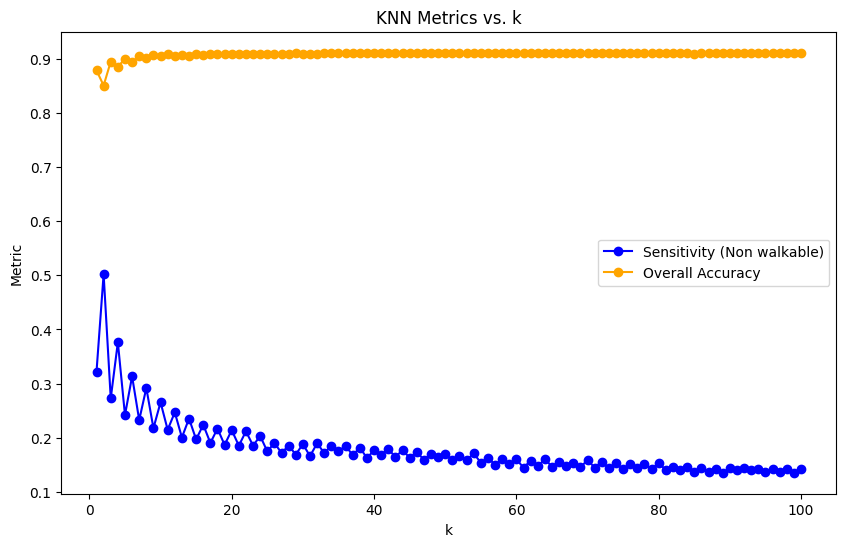

In [21]:
#Line plot to see it's only two lines
plt.figure(figsize=(10,6))
plt.plot(K_Values, Sensitivity_LeastWalkable, label='Sensitivity (Non walkable)', color='blue', marker='o')
plt.plot(K_Values, Overall_Accuracy, label='Overall Accuracy', color='orange', marker='o')
plt.xlabel("k")
plt.ylabel("Metric")
plt.title("KNN Metrics vs. k")
plt.legend()
plt.show()


In [22]:
#KNN with Original Data Sensitivity Rate of the Important Class
maxSensitivity = max(Sensitivity_LeastWalkable)
k_maxSensitivity = Sensitivity_LeastWalkable.index(maxSensitivity) + 1
print("Maximum Sensitivity (Least Walkable) =", maxSensitivity)
print("Occurs at k =", k_maxSensitivity)

Maximum Sensitivity (Least Walkable) = 0.5021459227467812
Occurs at k = 2


In [23]:
#KNN with Original Data Overall Accuracy Rate
maxAccuracy = max(Overall_Accuracy)
k_maxAccuracy = Overall_Accuracy.index(maxAccuracy)+1
print("Maximum Overall Accuracy =", maxAccuracy)
print("Occurs at k =", k_maxAccuracy)

Maximum Overall Accuracy = 0.9115548236585701
Occurs at k = 49


In [24]:
#Choose k for specific metrics
Sensitivity_k = 2
Accuracy_k = 49
print('k = ', Sensitivity_k)
print('    Sensitivity (Non Walkable):', Sensitivity_LeastWalkable[Sensitivity_k-1])
print('    Overall Accuracy Rate:', Overall_Accuracy[Sensitivity_k-1])
print('')
print('k = ', Accuracy_k)
print('    Sensitivity (Non Walkable):', Sensitivity_LeastWalkable[Accuracy_k-1])
print('    Overall Accuracy Rate:', Overall_Accuracy[Accuracy_k-1])


k =  2
    Sensitivity (Non Walkable): 0.5021459227467812
    Overall Accuracy Rate: 0.8508988609853163

k =  49
    Sensitivity (Non Walkable): 0.16380543633762518
    Overall Accuracy Rate: 0.9115548236585701


In [25]:
#Choosing best k
combined_original = np.array(Overall_Accuracy) + np.array(Sensitivity_LeastWalkable)
best_k_original = int(np.argmax(combined_original) + 1)
print("Best combined metric k (original):", best_k_original)
print("Accuracy:", Overall_Accuracy[best_k_original-1])
print("Sensitivity:", Sensitivity_LeastWalkable[best_k_original-1])


Best combined metric k (original): 2
Accuracy: 0.8508988609853163
Sensitivity: 0.5021459227467812


### **KNN- Normalized Data**
Since KNN is distance-based, predictors with larger scales can dominate. We standardize using StandardScaler and repeat the k search.

In [26]:
from sklearn.preprocessing import StandardScaler
#Normalize the predictors
scaler = StandardScaler()
tune_smart_norm = scaler.fit_transform(tune_smart_predictor_vars)
validation_smart_norm = scaler.transform(validation_smart_predictor_vars)


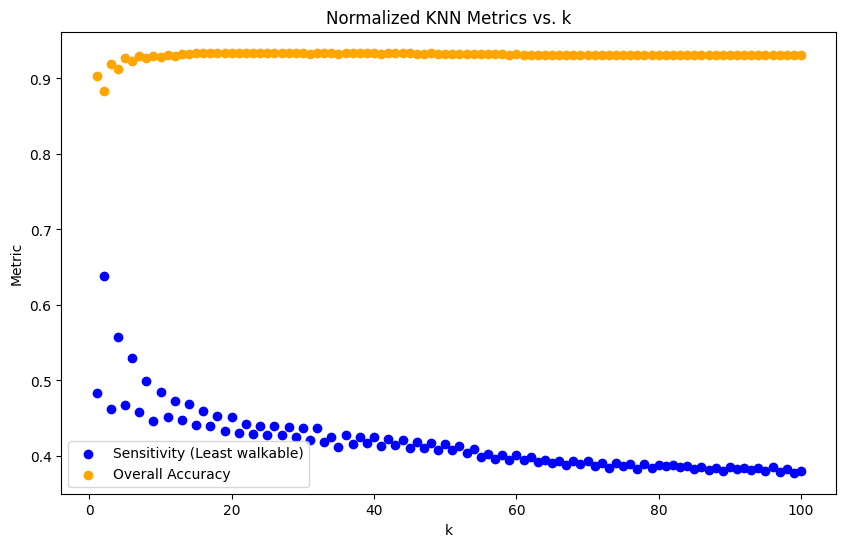

In [27]:
#Normalized KNN: tuning k from 1 to 100 using standardized predictors
#Initialize lists for results
K_Values_norm = []
Sensitivity_LeastWalkable_norm = []
Overall_Accuracy_norm = []

tune_smart_predictor_vars = train_smart_tune[["D1D", "D2B_E5MIX", "D3B", "D4A"]]
validation_smart_predictor_vars = train_smart_validation[["D1D", "D2B_E5MIX", "D3B", "D4A"]]

important_class = 0

for k in range(1, 101):
    est = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model = est.fit(tune_smart_norm, train_smart_tune["Walkability"])
    classifications = model.predict(validation_smart_norm)
    df = pd.DataFrame({
        'Actual': train_smart_validation['Walkability'],
        'Predictions': classifications
    })
    class_matrix = pd.crosstab(df['Actual'], df['Predictions'])
    K_Values_norm.append(k)
    Overall_Accuracy_norm.append((class_matrix.at[0, 0] + class_matrix.at[1, 1])/len(train_smart_validation))
    Sensitivity_LeastWalkable_norm.append(class_matrix.at[0, 0]/(class_matrix.at[0, 0]+class_matrix.at[0, 1]))
#Plot
plt.figure(figsize=(10,6))
plt.scatter(K_Values_norm, Sensitivity_LeastWalkable_norm, label='Sensitivity (Least walkable)', color='blue')
plt.scatter(K_Values_norm, Overall_Accuracy_norm, label='Overall Accuracy', color='orange')
plt.xlabel("k")
plt.ylabel("Metric")
plt.title("Normalized KNN Metrics vs. k")
plt.legend()
plt.show()

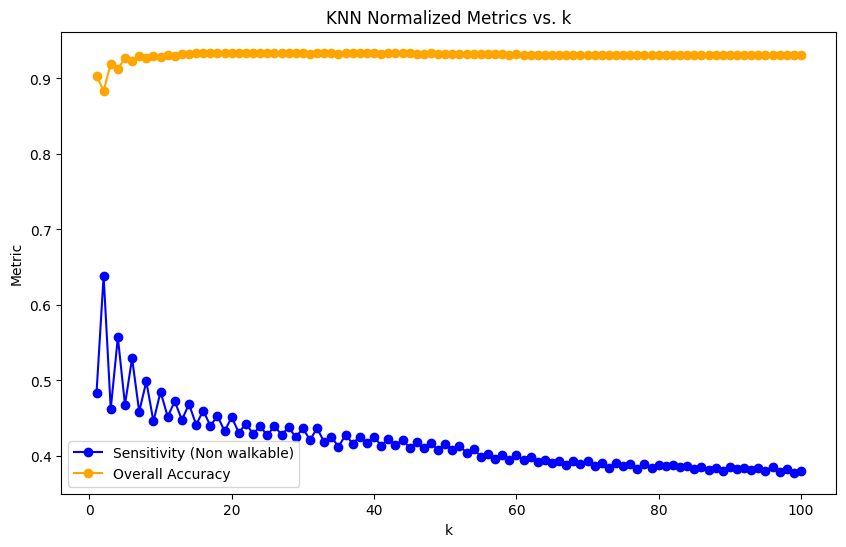

In [28]:
#Normalized KNN Lineplot
plt.figure(figsize=(10,6))
plt.plot(K_Values_norm, Sensitivity_LeastWalkable_norm, label='Sensitivity (Non walkable)', color='blue', marker='o')
plt.plot(K_Values_norm, Overall_Accuracy_norm, label='Overall Accuracy', color='orange', marker='o')
plt.xlabel("k")
plt.ylabel("Metric")
plt.title("KNN Normalized Metrics vs. k")
plt.legend()
plt.show()

In [29]:
#KNN with Normalized Data Overall Accuracy Rate
maxAccuracy_norm = max(Overall_Accuracy_norm)
k_maxAccuracy_norm = Overall_Accuracy_norm.index(maxAccuracy_norm)+1
print("Maximum Overall Accuracy =", maxAccuracy_norm)
print("Occurs at k =", k_maxAccuracy_norm)


Maximum Overall Accuracy = 0.9341292713050638
Occurs at k = 26


In [30]:
#KNN with Normalized Data Maximum Sensitivity Rate
maxSensitivity_norm = max(Sensitivity_LeastWalkable_norm)
k_maxSensitivity_norm = Sensitivity_LeastWalkable_norm.index(maxSensitivity_norm) + 1
print("Maximum Sensitivity (Least Walkable) =", maxSensitivity_norm)
print("Occurs at k =", k_maxSensitivity_norm)


Maximum Sensitivity (Least Walkable) = 0.6387696709585121
Occurs at k = 2


In [31]:
#Choose k for specific metrics
maxSensitivity_norm = 2
maxAccuracy_norm = 26
print('k = ', maxSensitivity_norm)
print('    Sensitivity (Least Walkable):', Sensitivity_LeastWalkable_norm[maxSensitivity_norm - 1])
print('    Overall Accuracy Rate:', Overall_Accuracy_norm[maxSensitivity_norm - 1])
print('')

print('k = ', maxAccuracy_norm)
print('    Sensitivity (Least Walkable):', Sensitivity_LeastWalkable_norm[maxAccuracy_norm - 1])
print('    Overall Accuracy Rate:', Overall_Accuracy_norm[maxAccuracy_norm - 1])


k =  2
    Sensitivity (Least Walkable): 0.6387696709585121
    Overall Accuracy Rate: 0.8838342253327844

k =  26
    Sensitivity (Least Walkable): 0.43991416309012876
    Overall Accuracy Rate: 0.9341292713050638


In [32]:
#Finding best k in Normalized KNN
combined_norm = np.array(Overall_Accuracy_norm) + np.array(Sensitivity_LeastWalkable_norm)
best_k_norm = int(np.argmax(combined_norm) + 1)
print("Best combined metric k (normalized):", best_k_norm)
print("Accuracy:", Overall_Accuracy_norm[best_k_norm-1])
print("Sensitivity:", Sensitivity_LeastWalkable_norm[best_k_norm-1])


Best combined metric k (normalized): 2
Accuracy: 0.8838342253327844
Sensitivity: 0.6387696709585121


###**Decision Tree**
We fit a classification tree, tuning max_depth and pruning via cost-complexity pruning (alpha) to avoid overfitting. The simplified tree is also visualized for interpretability.

In [33]:
test_smart_predictor_variables = test_smart[test_smart.columns.drop("Walkability")]
train_smart_predictor_variables = train_smart[train_smart.columns.drop("Walkability")]

In [34]:
predictors = ["D1D", "D2B_E5MIX", "D3B", "D4A"]

X_tune = train_smart_tune[predictors]
y_tune = train_smart_tune["Walkability"]

X_valid = train_smart_validation[predictors]
y_valid = train_smart_validation["Walkability"]


In [35]:
#Finding best max_depth for Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = range(1, 21)
validation_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=0)
    model.fit(X_tune, y_tune)
    preds = model.predict(X_valid)
    acc = accuracy_score(y_valid, preds)
    validation_acc.append(acc)

best_depth = depths[np.argmax(validation_acc)]
print("Best max_depth:", best_depth)
print("Best validation accuracy:", max(validation_acc))


Best max_depth: 7
Best validation accuracy: 0.9327569644572526


In [36]:
#Train the final decision tree using the best max_depth found above
final_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=0)
final_tree.fit(X_tune, y_tune)


DecisionTreeClassifier(max_depth=7, random_state=0)

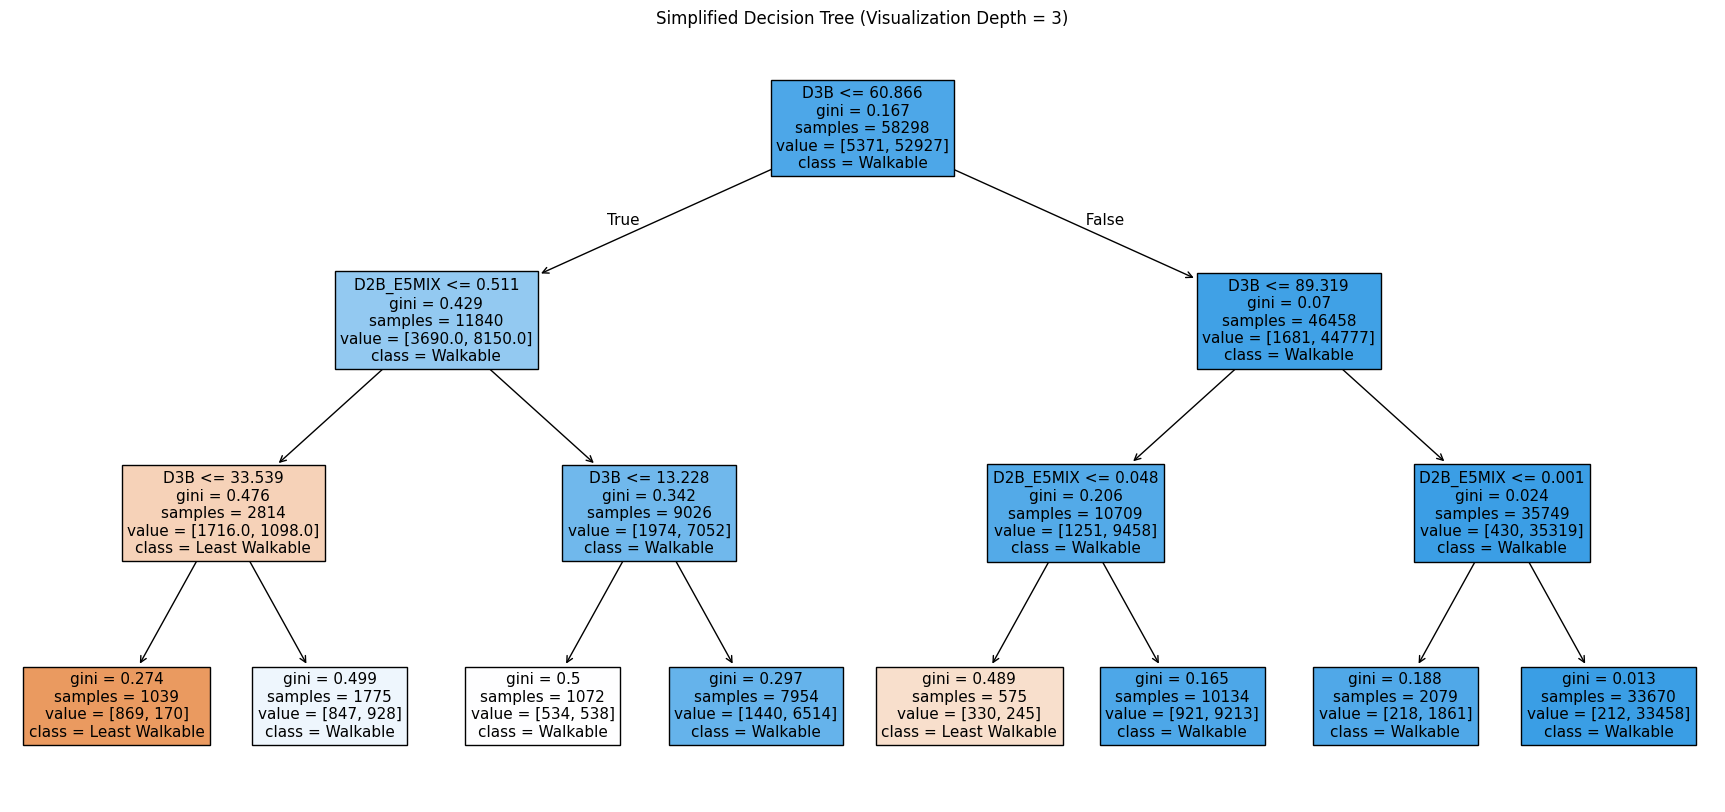

In [37]:
from sklearn.tree import plot_tree

#Visualization-only decision tree (shallower) (only few nodes)
viz_tree = DecisionTreeClassifier(max_depth=3, random_state=0)
viz_tree.fit(X_tune, y_tune)

plt.figure(figsize=(22, 10))
plot_tree(
    viz_tree,
    feature_names=predictors,
    class_names=["Least Walkable", "Walkable"],
    filled=True,
    fontsize=11
)
plt.title("Simplified Decision Tree (Visualization Depth = 3)")
plt.show()


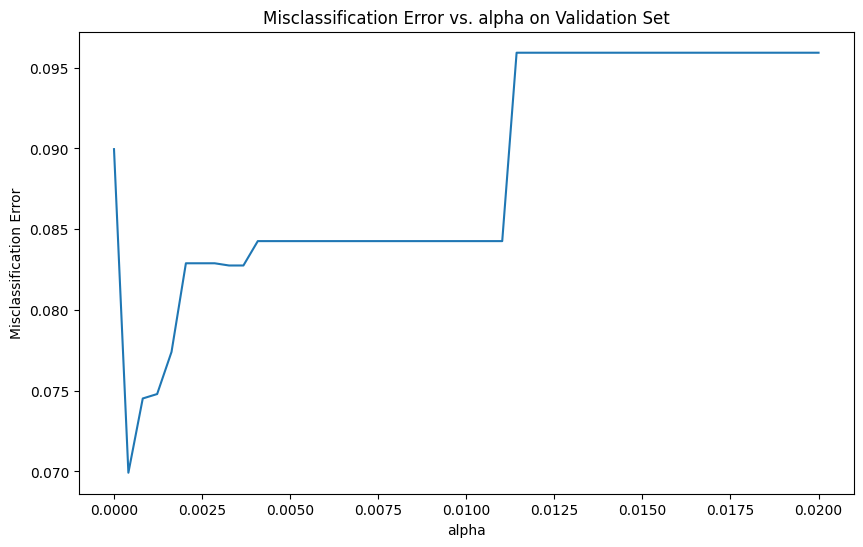

Best alpha: 0.00040816326530612246


In [41]:
tune_predictors = X_tune
val_predictors = X_valid
tune_outcome = y_tune
val_outcome = y_valid
#Create the alpha set and calculate misclassification errors
alpha_set = np.linspace(0, 0.02, 50)
val_misclassification = []

for alpha in alpha_set:
    est = DecisionTreeClassifier(ccp_alpha=alpha, random_state=0)
    model = est.fit(tune_predictors, tune_outcome)
    val_preds = model.predict(val_predictors)

    #Misclassification error instead of MSE
    misclass = 1 - accuracy_score(val_outcome, val_preds)
    val_misclassification.append(misclass)

#Plot the Misclassification Error vs. Alpha
plt.figure(figsize=(10,6))
plt.plot(alpha_set, val_misclassification)
plt.xlabel('alpha')
plt.ylabel('Misclassification Error')
plt.title('Misclassification Error vs. alpha on Validation Set')
plt.show()

#Find and print the best alpha
min_value = min(val_misclassification)
best_index = val_misclassification.index(min_value)
best_alpha = alpha_set[best_index]
print("Best alpha:", best_alpha)

## **Baseline Model: The Problem with Unconstrained Trees**
First, we trained a standard Decision Tree without limiting its depth or leaf nodes. As seen below, this results in a highly overfitted model that essentially memorizes the training data. The resulting tree is a massive, unreadable web that offers zero interpretable business value. This highlights the need for cost-complexity pruning and leaf-node limitations.

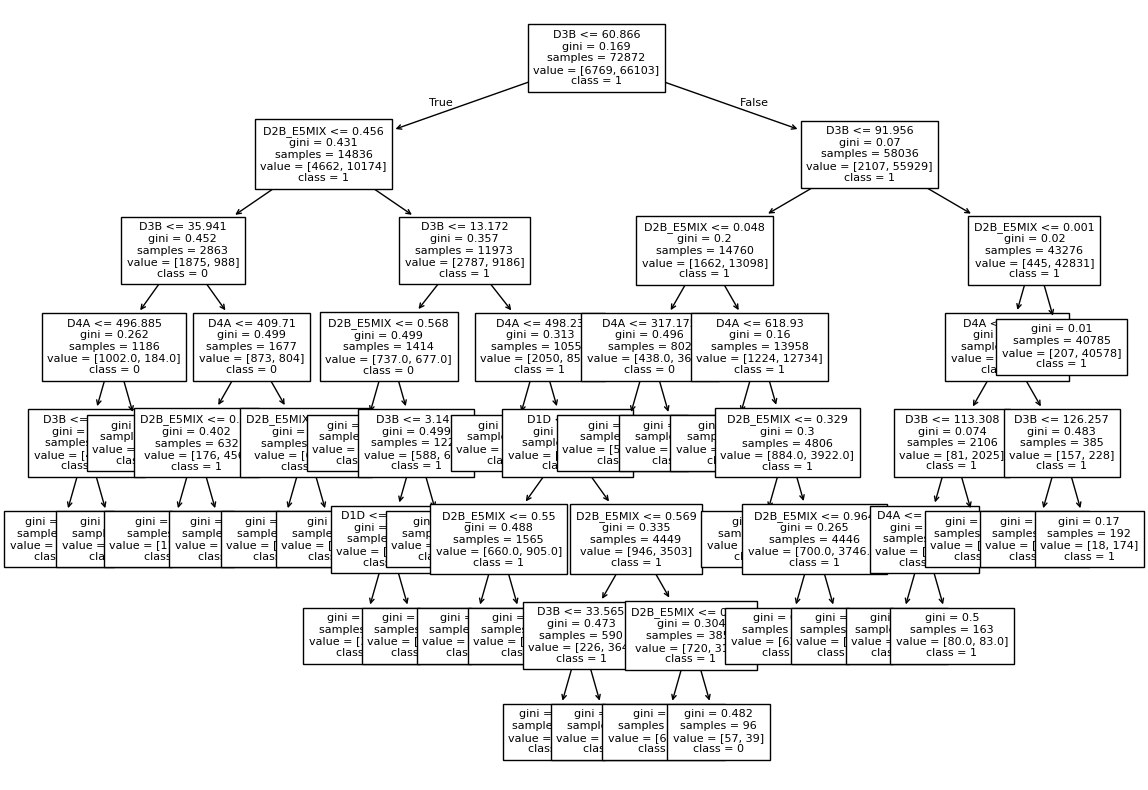

In [42]:
from sklearn import tree

#Train Pruned Tree using the best_alpha found in the previous cell
train_predictors = train_smart[["D1D", "D2B_E5MIX", "D3B", "D4A"]]
train_outcome = train_smart["Walkability"]

final_tree_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=0)
final_tree_pruned.fit(train_predictors, train_outcome)

#Plot the final Pruned Tree
plt.figure(figsize=(14,10))
tree.plot_tree(final_tree_pruned, fontsize=8, feature_names=train_predictors.columns, class_names=["0","1"])
plt.show()

## **Final Interpretable Model: 8-Node Decision Tree**
To resolve the overfitting issue and extract actionable insights, we constrained the model to a maximum of 8 leaf nodes. This forces the algorithm to only split on the most critical thresholds, creating a clean, interpretable model that clearly identifies Street Connectivity (D3B) as the primary driving factor for walkability.

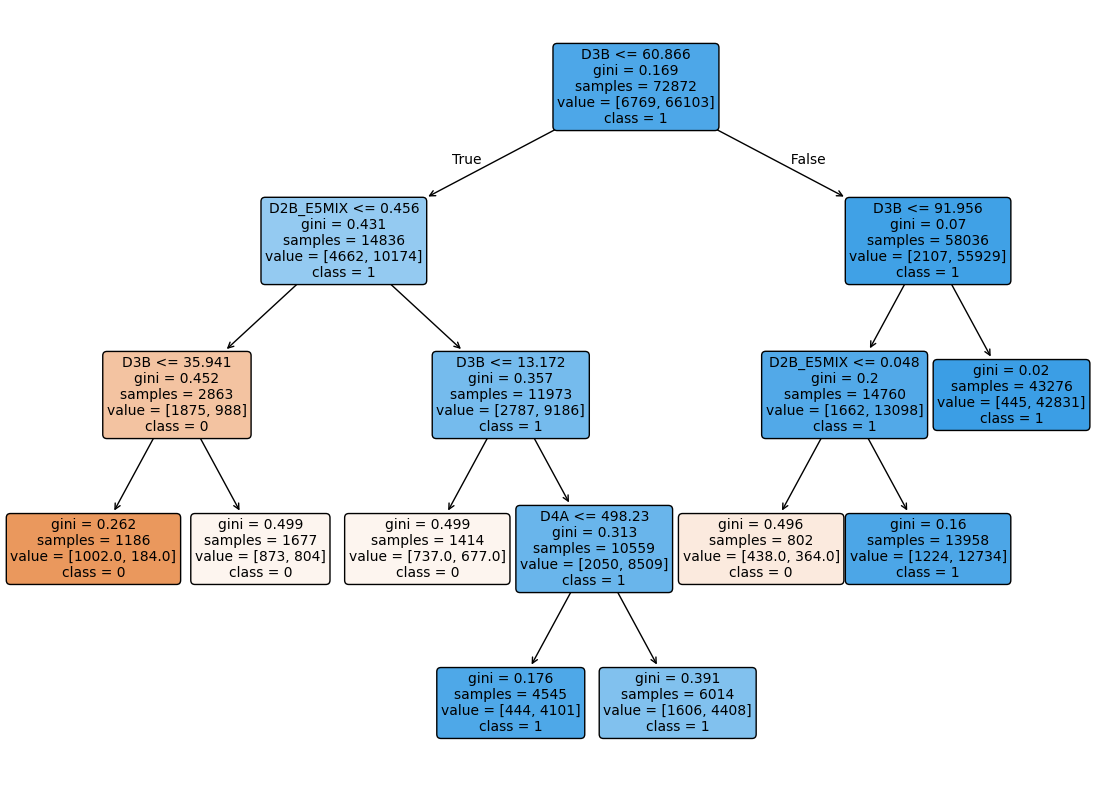

In [58]:
#Train an interpretable tree with 8 terminal nodes
train_predictors = train_smart[["D1D", "D2B_E5MIX", "D3B", "D4A"]]
train_outcome = train_smart["Walkability"]

#Capping the leaf nodes cleans up the chart drastically
final_tree_pruned = DecisionTreeClassifier(max_leaf_nodes=8, random_state=0)
final_tree_pruned.fit(train_predictors, train_outcome)

plt.figure(figsize=(14,10))
tree.plot_tree(
    final_tree_pruned,
    fontsize=10,
    feature_names=train_predictors.columns,
    class_names=["0","1"],
    filled=True,
    rounded=True
)
plt.show()

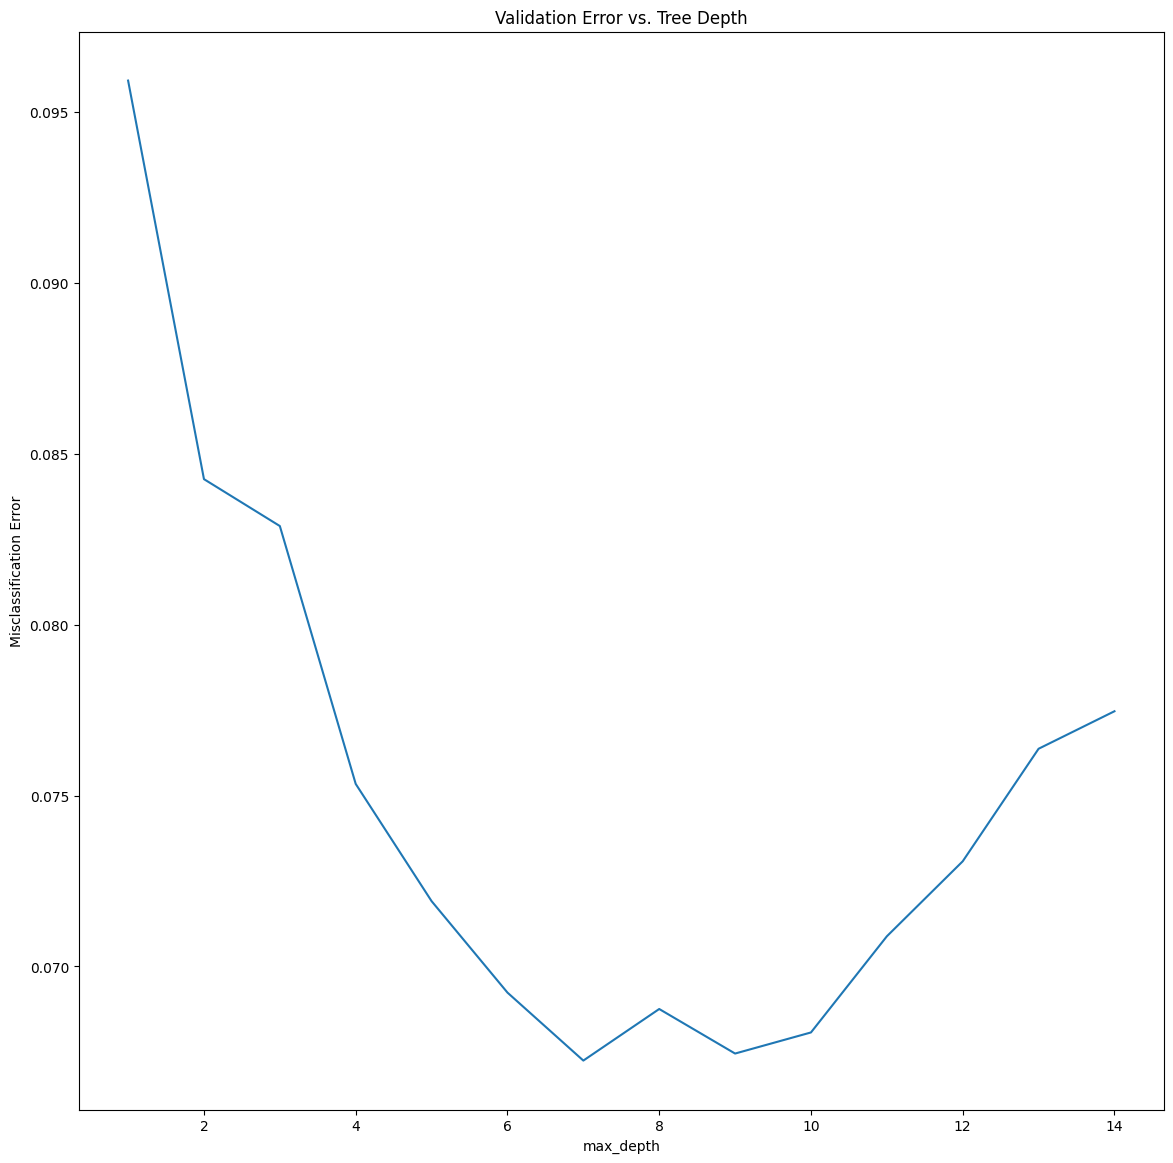

7

In [72]:
#Confirm Validation Error vs Tree Depth
depths = range(1, 15)
val_errors_depth = []

for d in depths:
    est = DecisionTreeClassifier(max_depth=d, random_state=0)
    model = est.fit(tune_predictors, tune_outcome)
    preds = model.predict(val_predictors)

    val_errors_depth.append(1 - accuracy_score(val_outcome, preds))

plt.plot(depths, val_errors_depth)
plt.xlabel("max_depth")
plt.ylabel("Misclassification Error")
plt.title("Validation Error vs. Tree Depth")
plt.show()

best_depth = depths[val_errors_depth.index(min(val_errors_depth))]
best_depth


In [44]:
#See Feature Importance Scores
import pandas as pd

feature_importances = pd.DataFrame({
    'Feature': predictors,
    'Importance': final_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)


     Feature  Importance
2        D3B    0.500394
1  D2B_E5MIX    0.304251
3        D4A    0.160907
0        D1D    0.034449


### **Bagged Trees**
Bagging reduces variance by averaging over many trees. We tune n_estimators using GridSearchCV on a 30% subsample for speed, then evaluate feature importances as the average across all trees.

In [45]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

#Using 30% subsample for speed - full tuning set takes too long to run
X_tune_small = X_tune.sample(frac=0.3, random_state=0)
y_tune_small = y_tune.loc[X_tune_small.index]

base_tree = DecisionTreeClassifier(random_state=0)
param_grid = {'n_estimators': [10, 50, 100]}

#Bagging classifier (n_jobs=-1 to run quicker)
bagged_estimator = BaggingClassifier(estimator=base_tree, random_state=0, n_jobs=-1)

#3-fold CV to run quicker
tuning_output_bagged = GridSearchCV(bagged_estimator, param_grid, cv=3)
tuning_output_bagged.fit(X_tune_small, y_tune_small)

best_n_bagged = tuning_output_bagged.best_params_['n_estimators']
print("Optimal n_estimators for Bagged Tree:", best_n_bagged)

#Retrain on full tuning set
final_bagged = BaggingClassifier(estimator=base_tree, n_estimators=best_n_bagged, random_state=0, n_jobs=-1)
final_bagged.fit(X_tune, y_tune)

val_preds = final_bagged.predict(X_valid)
val_acc = accuracy_score(y_valid, val_preds)
print("Bagged Tree Validation Accuracy:", val_acc)


Optimal n_estimators for Bagged Tree: 100
Bagged Tree Validation Accuracy: 0.9336489639083299


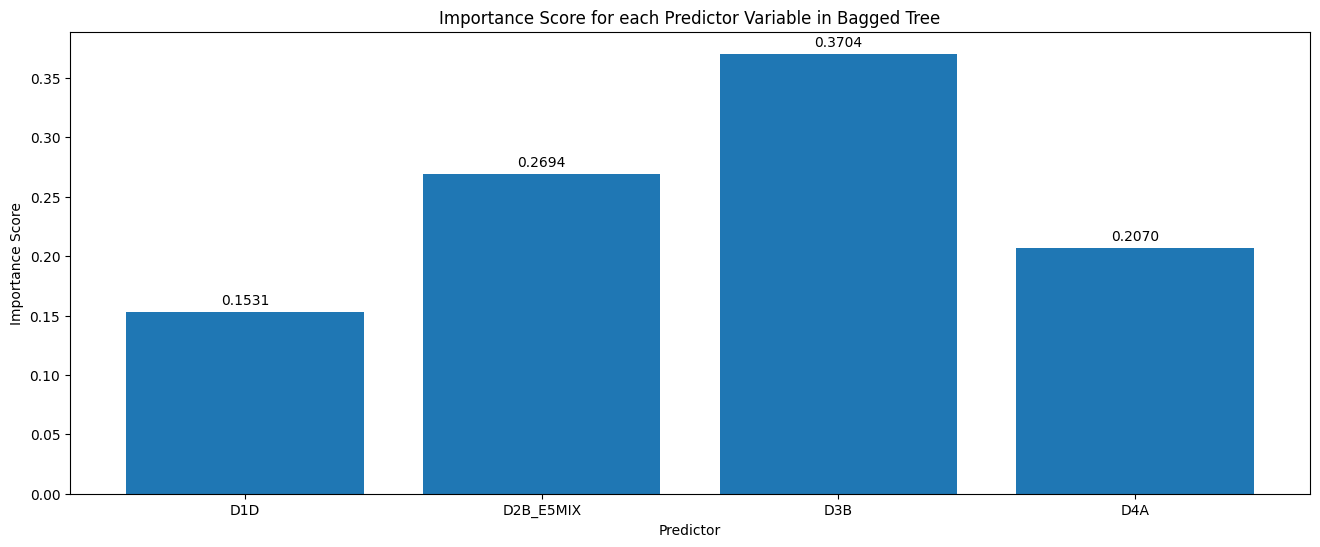

In [61]:
#Bagged Feature Importances (Average Feature Importance of each Decision Tree)
model_bagged = tuning_output_bagged.best_estimator_
tree_importances = np.array([tree.feature_importances_ for tree in model_bagged.estimators_])
mean_importances = np.mean(tree_importances, axis=0)
plt.rcParams["figure.figsize"] = (16,6)
bars = plt.bar(X_tune.columns, mean_importances)
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.xlabel('Predictor')
plt.ylabel('Importance Score')
plt.title('Importance Score for each Predictor Variable in Bagged Tree')

plt.show()

### **Random Forest**
Random Forest further reduces correlation between trees by randomly selecting a subset of predictors at each split (max_features='sqrt'). We tune n_estimators.

In [48]:
#Modeling Random Forest
from sklearn.ensemble import RandomForestClassifier
parameters = {'n_estimators': [10, 100, 1000]}
rf_base = RandomForestClassifier(max_features='sqrt', random_state=0)
tuning_rf = GridSearchCV(rf_base, parameters, cv=5)
rf_model = tuning_rf.fit(X_tune, y_tune).best_estimator_


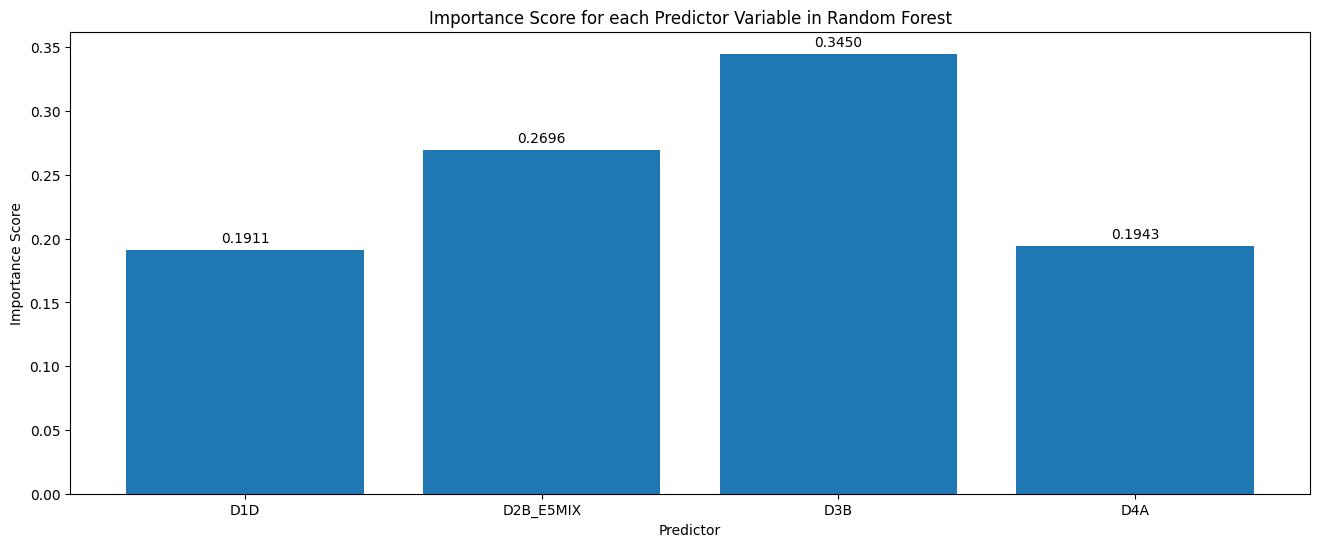

In [63]:
#Importance Scores for Predictors - RF
importances = rf_model.feature_importances_
plt.rcParams["figure.figsize"] = (16,6)
bars = plt.bar(X_tune.columns, importances)
plt.bar_label(bars, fmt='%.4f', padding=3)
plt.xlabel('Predictor')
plt.ylabel('Importance Score')
plt.title('Importance Score for each Predictor Variable in Random Forest')

plt.show()

In [50]:
#Show best number of estimators
print("Best n_estimators:", tuning_rf.best_params_['n_estimators'])

Best n_estimators: 1000


### **Model Assessment**
All models are evaluated on the held-out test set (20% of data) using
Overall Accuracy and Sensitivity for the Non-Walkable class (class 0).

In [52]:
test_smart_outcome = test_smart["Walkability"]
test_smart_predictor_variables = test_smart[["D1D", "D2B_E5MIX", "D3B", "D4A"]]
train_smart_predictor_variables = train_smart[["D1D", "D2B_E5MIX", "D3B", "D4A"]]
train_smart_outcome = train_smart["Walkability"]


In [53]:
#Original KNN Final
final_knn_original = KNeighborsClassifier(n_neighbors=best_k_original, metric='euclidean')

final_knn_original.fit(train_smart[predictors], train_smart["Walkability"])

train_pred_orig = final_knn_original.predict(train_smart[predictors])
test_pred_orig  = final_knn_original.predict(test_smart[predictors])

train_acc_orig = np.mean(train_pred_orig == train_smart["Walkability"])
train_sens_orig = (
    sum((train_smart["Walkability"]==0) & (train_pred_orig==0)) /
    sum(train_smart["Walkability"]==0)
)

test_acc_orig = np.mean(test_pred_orig == test_smart["Walkability"])
test_sens_orig = (
    sum((test_smart["Walkability"]==0) & (test_pred_orig==0)) /
    sum(test_smart["Walkability"]==0)
)

print("Original KNN (k =", best_k_original, ")")
print(" Train Accuracy:", train_acc_orig)
print(" Train Sensitivity:", train_sens_orig)
print(" Test Accuracy:", test_acc_orig)
print(" Test Sensitivity:", test_sens_orig)


Original KNN (k = 2 )
 Train Accuracy: 0.9415276100559886
 Train Sensitivity: 1.0
 Test Accuracy: 0.8503677681413986
 Test Sensitivity: 0.4946908182386009


In [54]:
#Normalize full training + test set
scaler_full = StandardScaler()
train_norm = scaler_full.fit_transform(train_smart[predictors])
test_norm = scaler_full.transform(test_smart[predictors])

#Normalized KNN Final
final_knn_norm = KNeighborsClassifier(n_neighbors=best_k_norm, metric='euclidean')
final_knn_norm.fit(train_norm, train_smart["Walkability"])

train_pred_norm = final_knn_norm.predict(train_norm)
test_pred_norm  = final_knn_norm.predict(test_norm)

train_acc_norm = np.mean(train_pred_norm == train_smart["Walkability"])
train_sens_norm = (
    sum((train_smart["Walkability"]==0) & (train_pred_norm==0)) /
    sum(train_smart["Walkability"]==0)
)

test_acc_norm = np.mean(test_pred_norm == test_smart["Walkability"])
test_sens_norm = (
    sum((test_smart["Walkability"]==0) & (test_pred_norm==0)) /
    sum(test_smart["Walkability"]==0)
)

print("\nNormalized KNN (k =", best_k_norm, ")")
print(" Train Accuracy:", train_acc_norm)
print(" Train Sensitivity:", train_sens_norm)
print(" Test Accuracy:", test_acc_norm)
print(" Test Sensitivity:", test_sens_norm)



Normalized KNN (k = 2 )
 Train Accuracy: 0.9537133604127785
 Train Sensitivity: 1.0
 Test Accuracy: 0.8936765835986387
 Test Sensitivity: 0.6589631480324797


In [71]:
#Re-confirm best alpha value for reference in Model Assessment
alpha_set = np.linspace(0, 0.02, 50)
val_misclassification = []

for alpha in alpha_set:
    est = DecisionTreeClassifier(ccp_alpha=alpha, random_state=0)
    model = est.fit(tune_predictors, tune_outcome)
    preds = model.predict(val_predictors)
    misclass = 1 - accuracy_score(val_outcome, preds)
    val_misclassification.append(misclass)

best_alpha = alpha_set[np.argmin(val_misclassification)]
print("Best alpha:", best_alpha)



Best alpha: 0.00040816326530612246


In [65]:
from sklearn.metrics import confusion_matrix

#Better visualization of the results (separated)
def model_metrics(model, name):
    print("\n===============================")
    print(name)
    print("===============================\n")

    #Train predictions
    train_preds = model.predict(train_smart_predictor_variables)
    train_acc = accuracy_score(train_smart_outcome, train_preds)

    cm_train = confusion_matrix(train_smart_outcome, train_preds)
    sens_train = cm_train[0,0] / (cm_train[0,0] + cm_train[0,1])

    #Test predictions
    test_preds = model.predict(test_smart_predictor_variables)
    test_acc = accuracy_score(test_smart_outcome, test_preds)

    cm_test = confusion_matrix(test_smart_outcome, test_preds)
    sens_test = cm_test[0,0] / (cm_test[0,0] + cm_test[0,1])

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Sensitivity (class 0) – TRAIN: {sens_train:.4f}")
    print(f"Sensitivity (class 0) – TEST:  {sens_test:.4f}")

    return {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "sens_train": sens_train,
        "sens_test": sens_test
    }

#Run results for the models
results_tree = model_metrics(final_tree_pruned, "Decision Tree (Pruned)")
results_bagged = model_metrics(final_bagged, "Bagged Tree")
results_rf = model_metrics(rf_model, "Random Forest")



Decision Tree (Pruned)

Training Accuracy: 0.9211
Test Accuracy: 0.9255
Sensitivity (class 0) – TRAIN: 0.4506
Sensitivity (class 0) – TEST:  0.4460

Bagged Tree

Training Accuracy: 0.9867
Test Accuracy: 0.9386
Sensitivity (class 0) – TRAIN: 0.8963
Sensitivity (class 0) – TEST:  0.5128

Random Forest

Training Accuracy: 0.9511
Test Accuracy: 0.9371
Sensitivity (class 0) – TRAIN: 0.6191
Sensitivity (class 0) – TEST:  0.4903


### **Model Deployment**
We create a profile using the mean values of all predictors across the dataset and predict its walkability class using the best-performing model.

In [66]:
#Profile will be the mean of all predictors
predictors = ["D1D", "D2B_E5MIX", "D3B", "D4A"]
profile_means = clean_smart[predictors].mean()
print("Profile (mean values) for each predictor:")
print(profile_means)


Profile (mean values) for each predictor:
D1D           15.850185
D2B_E5MIX      0.638527
D3B          122.196730
D4A          469.612984
dtype: float64


In [67]:
#Predictor means (the profile)
profile_dict = {
    "D1D": [15.850185],
    "D2B_E5MIX": [0.638527],
    "D3B": [122.196730],
    "D4A": [469.612984]
}

profile_df = pd.DataFrame(profile_dict)

#Predict walkability using the trained Bagged Tree model
predicted_walkability = final_bagged.predict(profile_df)
predicted_probabilities = final_bagged.predict_proba(profile_df)

print("Predicted Walkability (0 = Least Walkable, 1 = Walkable):", predicted_walkability[0])
print("Prediction Probabilities:", predicted_probabilities[0])


Predicted Walkability (0 = Least Walkable, 1 = Walkable): 1
Prediction Probabilities: [0. 1.]


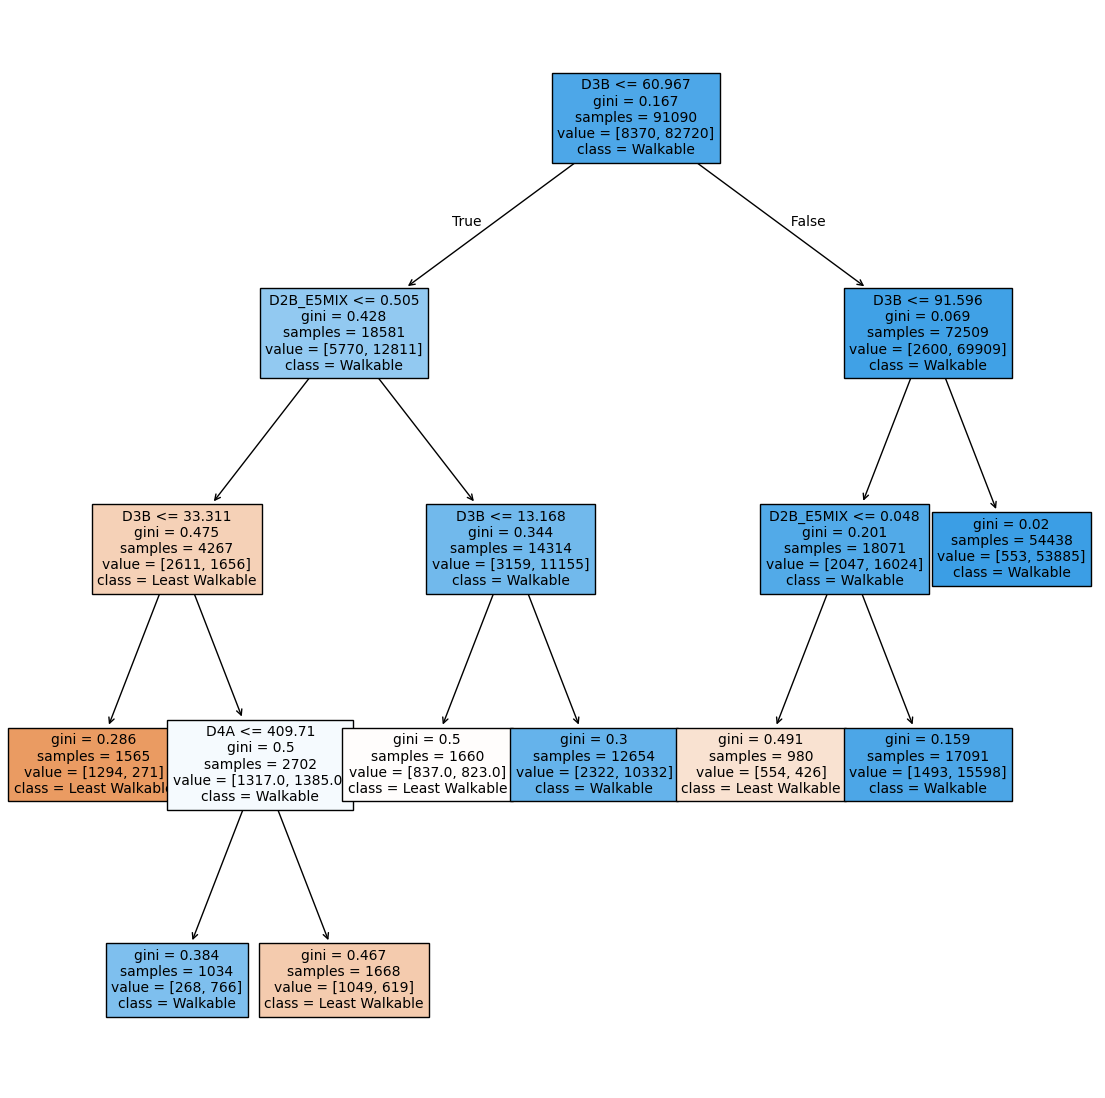

In [68]:
predictor_vars = clean_smart[['D1D', 'D2B_E5MIX', 'D3B', 'D4A']]
target_var = clean_smart['Walkability']

#Build a single interpretable decision tree with 8 terminal nodes
est = tree.DecisionTreeClassifier(random_state=0, max_leaf_nodes=8)
model = est.fit(predictor_vars, target_var)

plt.rcParams["figure.figsize"] = (14,14)
tree.plot_tree(
    model,
    feature_names=predictor_vars.columns,
    class_names=["Least Walkable", "Walkable"],
    filled=True,
    fontsize=10
)
plt.show()
